# 1. Imports and functions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
from dotenv import load_dotenv
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
from typing import List, Tuple

from wsd.load_data import load_data
from lineval.load_data import get_docs, docs_to_X_ys

from linpub.metrics import accuracy

from lineval.disambiguation_eval_backup import ClusterByMeaningModelv3
from lineval.disambiguation_eval_backup import OpenAiWordSenseComparatorv3, show_plots
from wsd.models import DummyComparator, ClusterByMeaningModel

from linalgo.hub.client import LinalgoClient

from etl.models import Candidate
from linalgo.annotate.models import Annotation

/home/jack/.pyenv/versions/3.10.6/envs/linpub/lib/python3.10/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'fr_dep_news_trf' (3.7.2) was trained with spaCy v3.7.0 and may not be 100% compatible with the current version (3.8.2). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [97]:
openai_api_key = os.getenv('OPEN_AI_API_KEY')
comp = OpenAiWordSenseComparatorv3(openai_api_key,
                                   openai_model='gpt-4o-mini',
                                   thought_process=False)
comp_4o = OpenAiWordSenseComparatorv3(openai_api_key,
                                      openai_model='gpt-4o',
                                      thought_process=False)
comp_4o_thought = OpenAiWordSenseComparatorv3(openai_api_key,
                                              openai_model='gpt-4o',
                                              thought_process=True)
comp_thought = OpenAiWordSenseComparatorv3(openai_api_key,
                                           openai_model='gpt-4o-mini',
                                           thought_process=True)
model1_1 = ClusterByMeaningModelv3(word_sense_comparator=comp)
model1_2 = ClusterByMeaningModelv3(word_sense_comparator=comp_4o)
model1_3 = ClusterByMeaningModelv3(word_sense_comparator=comp_4o_thought)
model1_4 = ClusterByMeaningModelv3(word_sense_comparator=comp_thought)

In [15]:
dummy2 = DummyComparator(probability=1)
model2 = ClusterByMeaningModel(comparator=dummy2)

dummy3 = DummyComparator(probability=0)
model3 = ClusterByMeaningModel(comparator=dummy3)

In [ ]:
def reduce_X_y(X: List[Candidate], y: List[int]) -> Tuple[List[Candidate], List[int]]:
    """Reduce X and y to rows of 3 examples and 2 meanings per lemma-pos pair

    Note: this is only for lagre datasets, as it is very selective.
    ------
    Parameters:
    X: List[Candidate]
        List of candidates
    y: List[int]
        List of labels
    ------
    Returns:
    Tuple[List[Candidate], List[int]]
        Balanced X and y
    """
    X_df = pd.DataFrame(X)

    # the models that I coded work with context, not examples
    X_df["context"] = [c.example for c in X]
    X_df = X_df.drop(columns=["example"])

    X_df["y"] = y
    X_df_len3 = X_df.groupby(["lemma", "pos"]).filter(lambda x: len(x) == 3)
    X_df_bl = pd.DataFrame()
    for _, group in X_df_len3.groupby(["lemma", "pos"]):
        if group["y"].nunique() == 2:
            #sort group by number of similar meanings
            group["count"] = group["y"].map(group["y"].value_counts())
            group = group.sort_values(by="count")
            # order will now be b/a/a or a/b/b so we just permute the first two
            group = pd.concat([group.iloc[[1]], group.iloc[[0]], group.iloc[[2]]])
            # order will now be a/b/a or b/a/b
            X_df_bl = pd.concat([X_df_bl, group])
    bl_y = X_df_bl["y"].to_list()
    cand_df = X_df_bl.drop(columns=["y", "count"])
    bl_X = [Candidate(**row) for row in cand_df.to_dict(orient="records")]
    return bl_X, bl_y

In [13]:
def v3_load_or_predict(file: str,
                       model : ClusterByMeaningModelv3,
                       X: List[Candidate]
                       ) -> Tuple[List[Candidate], List[int], pd.DataFrame]:
    """Load predictions from file or predict them

    Note: This function only works with v3 models,
    Other models just have predict and cannot load and outuput preds and process

    ------
    Parameters:
    file: str
        File path
    model: ClusterByMeaningModel
        Model to predict with
    X: List[Candidate]
        List of candidates
    ------
    Returns:
    Tuple[List[Candidate], List[int], pd.DataFrame]
        X, for when loaded from file
        y_pred,
        DataFrame with predictions and process
        """
    if os.path.exists(file):
        df = pd.read_csv(file)
        y_pred = df["y_pred"].to_list()
        process_lst = df["process"].to_list()
        pred_lst = df["pred"].to_list()
        df.drop(columns=["y_pred","process","pred"], inplace=True)
        X = [Candidate(**row) for row in df.to_dict(orient="records")]
        df = pd.DataFrame(X)
        df["process"] = process_lst
        df["pred"] = pred_lst
    else:
        X, y_pred = model.predict(X, verbose=True)
        df = pd.DataFrame(X)
        df["y_pred"] = y_pred
        df["pred"] = [c.pred for c in X]
        process_list = []
        for c in X:
            if not hasattr(c, "process"):
                process_list.append("NA")
            else :
                process_list.append(c.process)
        df["process"] = process_list
        df.to_csv(file, index=False)
    return X, y_pred, df

In [80]:
def get_f1_score(df, y, y_pred):
    X_df = df
    X_df["y"] = y
    X_df["y_pred"] = y_pred
    f1_y = []
    f1_y_pred = []
    for _, group in X_df.groupby(["lemma", "pos"]):
        pred1 = bool(group["y_pred"].iloc[1] == group["y_pred"].iloc[0])
        pred2 = bool(group["y_pred"].iloc[2] == group["y_pred"].iloc[0])
        f1_y.extend([False, True])
        f1_y_pred.extend([pred1, pred2])
    return f1_score(f1_y, f1_y_pred) , accuracy_score(f1_y, f1_y_pred)

def print_scores(df, y, y_pred1, y_pred2, y_pred3):
    print(f"--f1 scores--")
    print(f"Model: {get_f1_score(df, y, y_pred1)[0]}")
    print(f"Dummy(1): {get_f1_score(df, y, y_pred2)[0]}")
    print(f"Dummy(0): {get_f1_score(df, y, y_pred3)[0]}")
    print(f"--sklearn accuracy scores--")
    print(f"Model: {get_f1_score(df, y, y_pred1)[1]}")
    print(f"Dummy(1): {get_f1_score(df, y, y_pred2)[1]}")
    print(f"Dummy(0): {get_f1_score(df, y, y_pred3)[1]}")
    print(f"--linpub accuracy scores--")
    print(f"Model: {accuracy(y_pred1, y)}")
    print(f"Dummy(1): {accuracy(y_pred2, y)}")
    print(f"Dummy(0): {accuracy(y_pred3, y)}")

# 2. massaged dataset, new metric

## 2.1 load

In [5]:
X,y = load_data("fr")
for x in X :
    x.context = x.example
len(X), len(y)

(24266, 24266)

## 2.1.2 Exploration

Text(0.5, 1.0, 'Number of examples in pos/lemma groups')

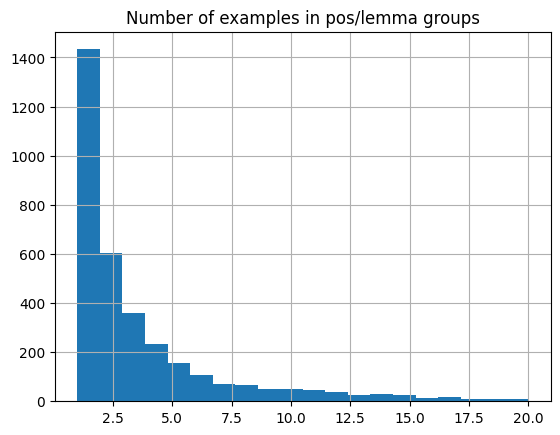

In [ ]:
# group by lemma and pos
X_df = pd.DataFrame(X)
X_df["y"] = y
cond = X_df.groupby(["lemma", "pos"]).size() <= 20# show only lemmas with more than 10 examples
X_df_20m = X_df.set_index(["lemma", "pos"]).loc[cond].reset_index()
X_df_20m.groupby(["lemma", "pos"]).size(). hist(bins=20)
plt.title("Number of examples in pos/lemma groups")

Text(0.5, 1.0, 'Number of examples in pos/lemma groups')

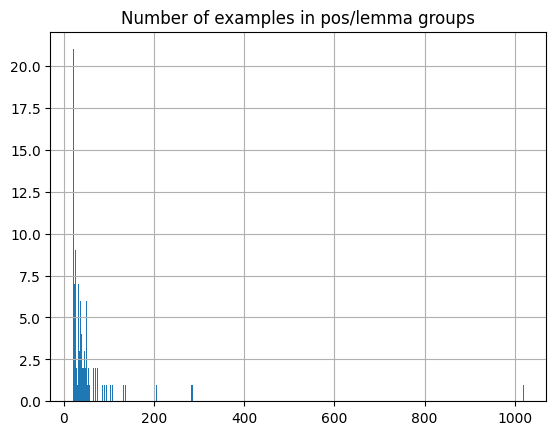

In [7]:
# group by lemma and pos
cond = X_df.groupby(["lemma", "pos"]).size() > 20# show only lemmas with more than 10 examples
X_df_20p = X_df.set_index(["lemma", "pos"]).loc[cond].reset_index()
X_df_20p.groupby(["lemma", "pos"]).size().hist(bins=1020)
plt.title("Number of examples in pos/lemma groups")

In [ ]:
# Top pos lemma group by number of rows
X_df.groupby(["lemma", "pos"]).size().sort_values(ascending=False).head(10)

lemma      pos 
dire       VERB    1020
sembler    VERB     343
commencer  VERB     311
voir       VERB     309
savoir     VERB     286
utiliser   VERB     284
penser     VERB     275
vouloir    VERB     218
essayer    VERB     206
homme      NOUN     173
dtype: int64

## 2.2 Dire (say) vs dire (tell)

In [9]:
X_df[X_df["lemma"] == "dire"]["y"].value_counts()

y
bn:00093287v\n    944
bn:00094862v\n     76
Name: count, dtype: int64

In [10]:
lone_cands = len(X_df.groupby(["lemma", "pos"]).filter(lambda x: len(x) == 1))
lone_cands, lone_cands/len(X_df)

(1433, 0.0590538201598945)

In [11]:
X_df[(X_df["lemma"] == "dire") & (X_df["y"] == "bn:00093287v\n")].head(20) #say

,pos,text,lemma,lemma_meaning,example,context,y
131,VERB,dit,dire,NA,"Il a pris le receveur et a dit , "" chef de la ...","Il a pris le receveur et a dit , "" chef de la ...",bn:00093287v\n
148,VERB,dit,dire,NA,""" Alors voilà "" , a -t -il dit .",""" Alors voilà "" , a -t -il dit .",bn:00093287v\n
150,VERB,dit,dire,NA,"Cependant probablement il était , Pauling dit ...","Cependant probablement il était , Pauling dit ...",bn:00093287v\n
161,VERB,dit,dire,NA,Madden a dit qu' il le verrait à deux heures e...,Madden a dit qu' il le verrait à deux heures e...,bn:00093287v\n
311,VERB,dit,dire,NA,"Sur parole charpentier Staffe , qui a dit qu' ...","Sur parole charpentier Staffe , qui a dit qu' ...",bn:00093287v\n
334,VERB,dit,dire,NA,Cook Bennett Mathues a dit que Juet avait préd...,Cook Bennett Mathues a dit que Juet avait préd...,bn:00093287v\n
478,VERB,dit,dire,NA,On ne dit presque rien de victoires spectacula...,On ne dit presque rien de victoires spectacula...,bn:00093287v\n
481,VERB,dit,dire,NA,George Meredith a dit que la ferveur est le cœ...,George Meredith a dit que la ferveur est le cœ...,bn:00093287v\n
642,VERB,dit,dire,NA,Je leur ai dit de beaux mensonges et ils ont t...,Je leur ai dit de beaux mensonges et ils ont t...,bn:00093287v\n
682,VERB,dit,dire,NA,""" S' il vous plaît "" , a -t -elle dit , "" S' i...",""" S' il vous plaît "" , a -t -elle dit , "" S' i...",bn:00093287v\n


In [12]:
X_df[(X_df["lemma"] == "dire") & (X_df["y"] != "bn:00093287v\n")].head(20) #tell

,pos,text,lemma,lemma_meaning,example,context,y
739,VERB,dit,dire,NA,"On nous a dit qu' à Pathet Lao , un Américain ...","On nous a dit qu' à Pathet Lao , un Américain ...",bn:00094862v\n
830,VERB,dire,dire,NA,""" J' ai vraiment quelque chose d' important à ...",""" J' ai vraiment quelque chose d' important à ...",bn:00094862v\n
835,VERB,dit,dire,NA,Elle me l' a dit .,Elle me l' a dit .,bn:00094862v\n
1271,VERB,dit,dire,NA,"Donc tout-important sont des idées , on nous d...","Donc tout-important sont des idées , on nous d...",bn:00094862v\n
1346,VERB,dit,dire,NA,"L'homme , on nous dit , est doué de raison et ...","L'homme , on nous dit , est doué de raison et ...",bn:00094862v\n
1735,VERB,dis,dire,NA,""" Je te le dis , tu veux laisser ça comme ça ,...",""" Je te le dis , tu veux laisser ça comme ça ,...",bn:00094862v\n
1854,VERB,dit,dire,NA,"Mais c' était un signe d' espoir , il s' est d...","Mais c' était un signe d' espoir , il s' est d...",bn:00094862v\n
2427,VERB,dit,dire,NA,L' énormité de ce que Conrad lui avait dit a r...,L' énormité de ce que Conrad lui avait dit a r...,bn:00094862v\n
2431,VERB,dit,dire,NA,Il savait que Conrad lui avait dit la vérité .,Il savait que Conrad lui avait dit la vérité .,bn:00094862v\n
2524,VERB,dit,dire,NA,"Elle n' a rien dit à personne , même à sa mère...","Elle n' a rien dit à personne , même à sa mère...",bn:00094862v\n


## 2.3 Creating a balanded set

In [69]:
X,y = load_data("fr")
bl_X, bl_y = reduce_X_y(X, y)
len(bl_X), len(bl_y)

(210, 210)

## 2.4 Running

In [70]:
X, y_pred1, df = v3_load_or_predict("results1_1.csv", model1_1, bl_X)

y_pred2 = model2.predict(bl_X, verbose=True)
y_pred3 = model3.predict(bl_X, verbose=True)

100%|██████████| 70/70 [00:00<00:00, 2304.85it/s]


## 2.4.2 Metrics

In [ ]:
print_scores(df, bl_y, y_pred1, y_pred2, y_pred3)

--f1 scores--
Model: 0.6598984771573604
Dummy(1): 0.6666666666666666
Dummy(0): 0.0
--sklearn accuracy scores--
Model: 0.5214285714285715
Dummy(1): 0.5
Dummy(0): 0.5
--linpub accuracy scores--
Model: 0.1585365853658537
Dummy(1): 0.0
Dummy(0): 0.33333333333333337


## 2.5 Plotting

In [86]:
#need to add the correct column to the dataframe
def add_correct_column(df, y_pred1, bl_y):
    correct_df = pd.DataFrame()
    for _, gp in df.groupby(["lemma", "pos"]):
        pred1 = gp["y_pred"].iloc[1] != gp["y_pred"].iloc[0]
        pred2 = gp["y_pred"].iloc[2] == gp["y_pred"].iloc[0]
        gp = gp.copy()  # To avoid SettingWithCopyWarning
        gp["correct"] = pd.Series(["ref", pred1, pred2], index=gp.index)
        correct_df = pd.concat([correct_df, gp])
    return correct_df
correct_df = add_correct_column(df, y_pred1, bl_y)
correct_df.head(3)

,id,lang,pos,text,text_meaning,text_romaji,text_hiragana,lemma,lemma_meaning,lemma_romaji,lemma_hiragana,example,context,annotation,document,status,process,pred,y,y_pred,correct
0,NaN,NaN,NOUN,Mississippi,NaN,NaN,NaN,Mississippi,1,NaN,NaN,NaN,"Un soldat de Mississippi a écrit: "" Notre géné...",NaN,NaN,pending,NaN,1.0,bn:00052763n\n,3000741937540482265,ref
1,NaN,NaN,NOUN,Mississippi,NaN,NaN,NaN,Mississippi,2,NaN,NaN,NaN,Raymond Vernon rapporte que les résidents de l...,NaN,NaN,pending,NaN,1.0,bn:00055331n\n,-8938361380067070926,True
2,NaN,NaN,NOUN,Mississippi,NaN,NaN,NaN,Mississippi,3,NaN,NaN,NaN,Mais en regardant Faulkner dans son arrière-pl...,NaN,NaN,pending,NaN,0.9,bn:00052763n\n,4615308664669784324,False


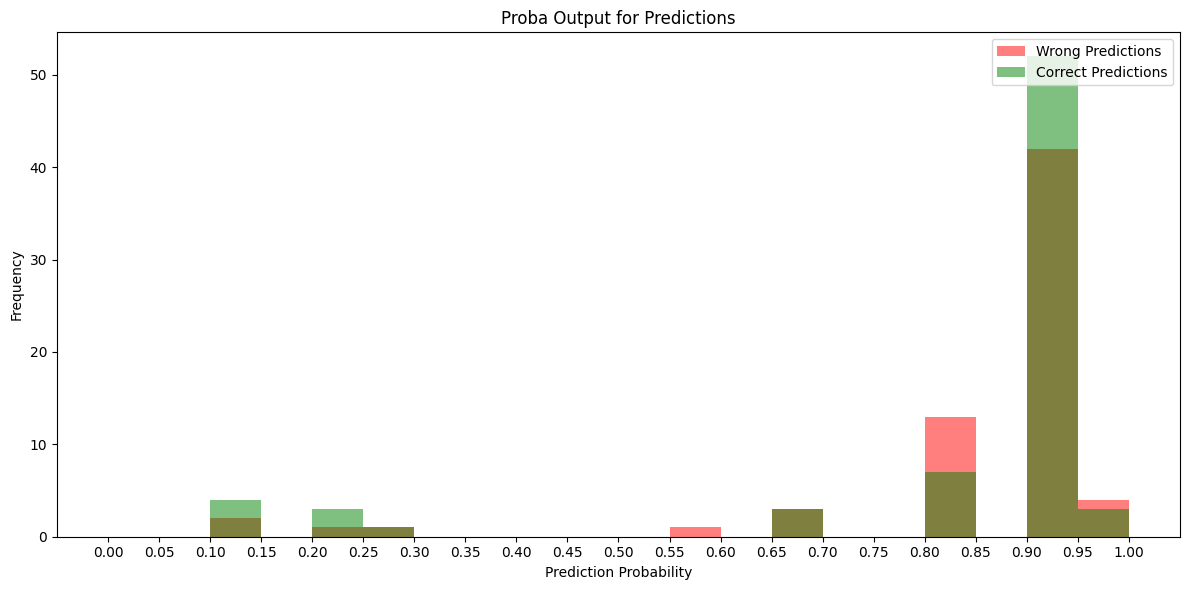

Displaying all clusters with at least one error
          text              y  pred correct                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 context  process
   Mississippi bn:00052763n\n  1.00     ref                                                                                                                                                                                                                                

In [63]:
show_plots(correct_df, errors=True)

## 2.6 For all models 🤘🔥🎸💀⚡

--f1 scores--
Model: 0.6598984771573604
Dummy(1): 0.6666666666666666
Dummy(0): 0.0
--sklearn accuracy scores--
Model: 0.5214285714285715
Dummy(1): 0.5
Dummy(0): 0.5
--linpub accuracy scores--
Model: 0.1585365853658537
Dummy(1): 0.0
Dummy(0): 0.33333333333333337


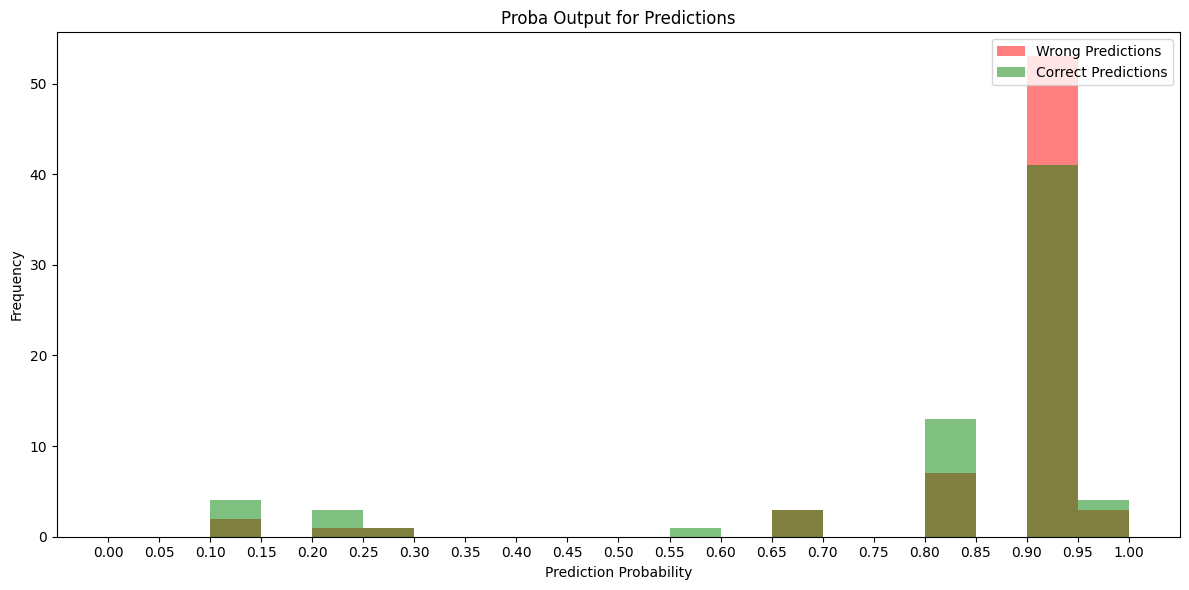

Displaying all clusters with at least one error
          text              y  pred correct                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 context  process
   Mississippi bn:00052763n\n  1.00     ref                                                                                                                                                                                                                                

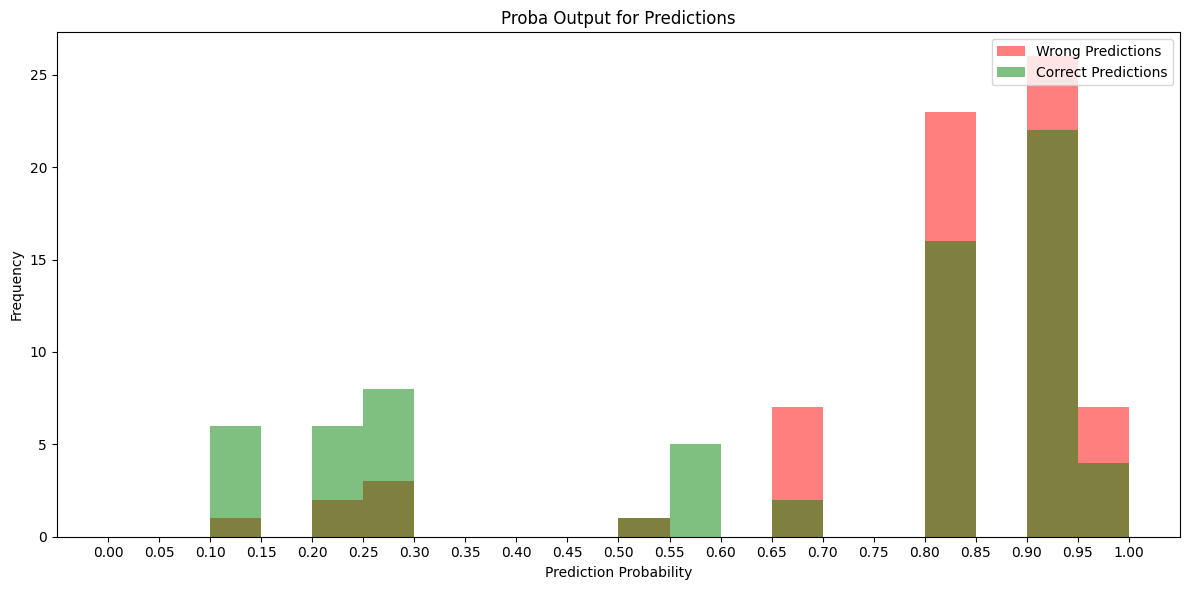

Displaying all clusters with at least one error
          text              y  pred correct                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 context  process
   Mississippi bn:00052763n\n  1.00     ref                                                                                                                                                                                                                                

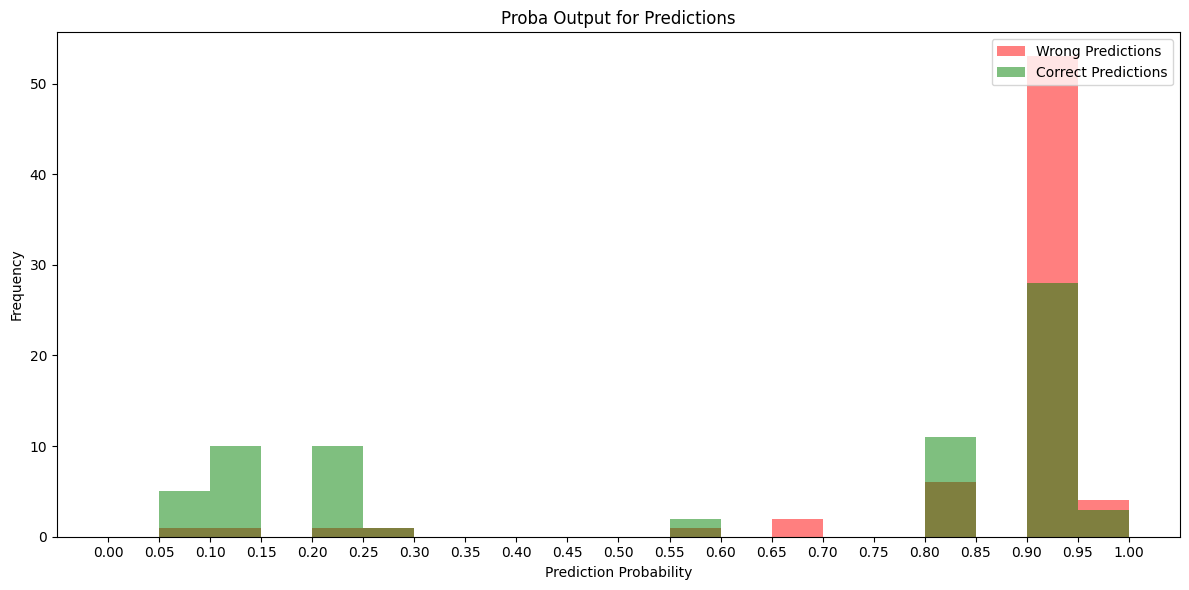

Displaying all clusters with at least one error
          text              y  pred correct                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 context                                                                                                                                                                                                                                                                                     

100%|██████████| 70/70 [07:40<00:00,  6.57s/it]


--f1 scores--
Model: 0.6524064171122995
Dummy(1): 0.6666666666666666
Dummy(0): 0.0
--sklearn accuracy scores--
Model: 0.5357142857142857
Dummy(1): 0.5
Dummy(0): 0.5
--linpub accuracy scores--
Model: 0.2282608695652174
Dummy(1): 0.0
Dummy(0): 0.33333333333333337


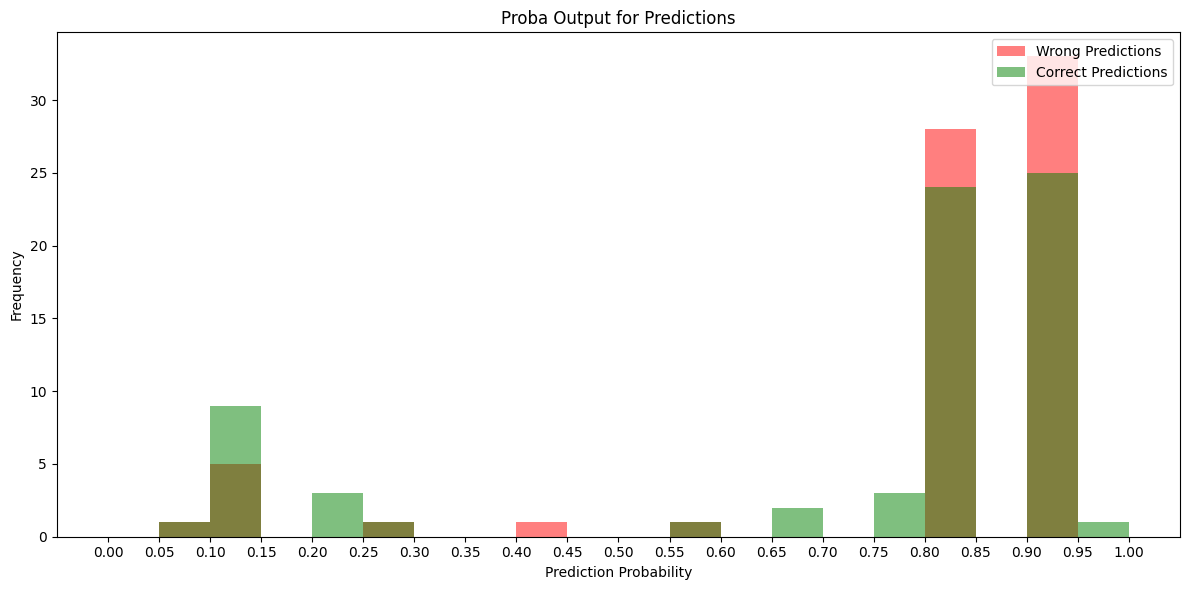

Displaying all clusters with at least one error
          text              y  pred correct                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 context                                                                                                                                                                                                                                                                                     

In [98]:
models = {"1_1": model1_1, "1_2": model1_2, "1_3": model1_3, "1_4": model1_4}

for key,value in models.items():
    # print(f"results_{key}.csv")
    X, y_pred, df = v3_load_or_predict(f"results{key}.csv", value, bl_X)
    print_scores(df, bl_y, y_pred, y_pred2, y_pred3)
    correct_df = add_correct_column(df, y_pred, bl_y)
    show_plots(correct_df, errors=True)

# 3. Linhub dataset

In [41]:
docs = get_docs()

Retrivieving task with id 85d7052e-b464-47a9-beca-dd8df8f8c632...
Retrieving annotators... (1 found)
Retrieving entities... (7 found)
Retrieving documents... (63 found)
Retrieving annotations... (144 found)


In [42]:
X, y_db, y_human = docs_to_X_ys(docs)
len(X), len(y_db), len(y_human)

(144, 144, 144)

In [43]:
y_human[:5]

[-5304580851180564469,
 -3296119327858113882,
 1839704710026214392,
 1839704710026214392,
 642753799874802209]

In [44]:
y_pred2 = model2.predict(X, verbose=True)
y_pred3 = model3.predict(X, verbose=True)
X, y_pred1, df = v3_load_or_predict("hub_results1_3.csv", model1_3, X)
len(df), len(X), len(y_pred1), len(y_pred2), len(y_pred3)

100%|██████████| 63/63 [00:00<00:00, 4665.27it/s]


100%|██████████| 63/63 [00:00<00:00, 3454.67it/s]


(144, 144, 144, 144, 144)

In [45]:
print("-----accuracies-----")
print(f"Our model : {round(accuracy(y_pred1, y_human),2)}")
print(f"Dummy(1) : {round(accuracy(y_pred2, y_human),2)}")
print(f"Dummy(0) : {round(accuracy(y_pred3, y_human),2)}")

-----accuracies-----
Our model : 0.73
Dummy(1) : 0.48
Dummy(0) : 0.42


# Conclusions


-------
1. base mdel and data

1.1 The dummy 1 is better that the model at 91% vs 90%

1.2 The dataset is unbalanced

1.3 The model errors seem to be due to errors in the y

-------
2. balancing the dataset

2.1. There are 1433 dual candidates, ~6% of the dataset

2.2 The top pos/lemma group is dire, with 1020 rows (2 different meanings)(944of the main maining, and then 74 of the 2nd) (say vs tell)

2.3 From the pos/lemma groups with 3 rows and 2 meanings, (210 rows) I made a balanced, ordered dataset where the model will have to do 2 outputs: 0 then 1 

2.4. The model is barely better than the baseline